D:\py\Anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\py\Anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


📂 Loading original Excel to determine total IDs...
✅ 检测到有效测点数量: 81 个。

📊 Calculating Metrics for Model Validation Comparison (Train vs Test Set) (Train vs Group 7)...


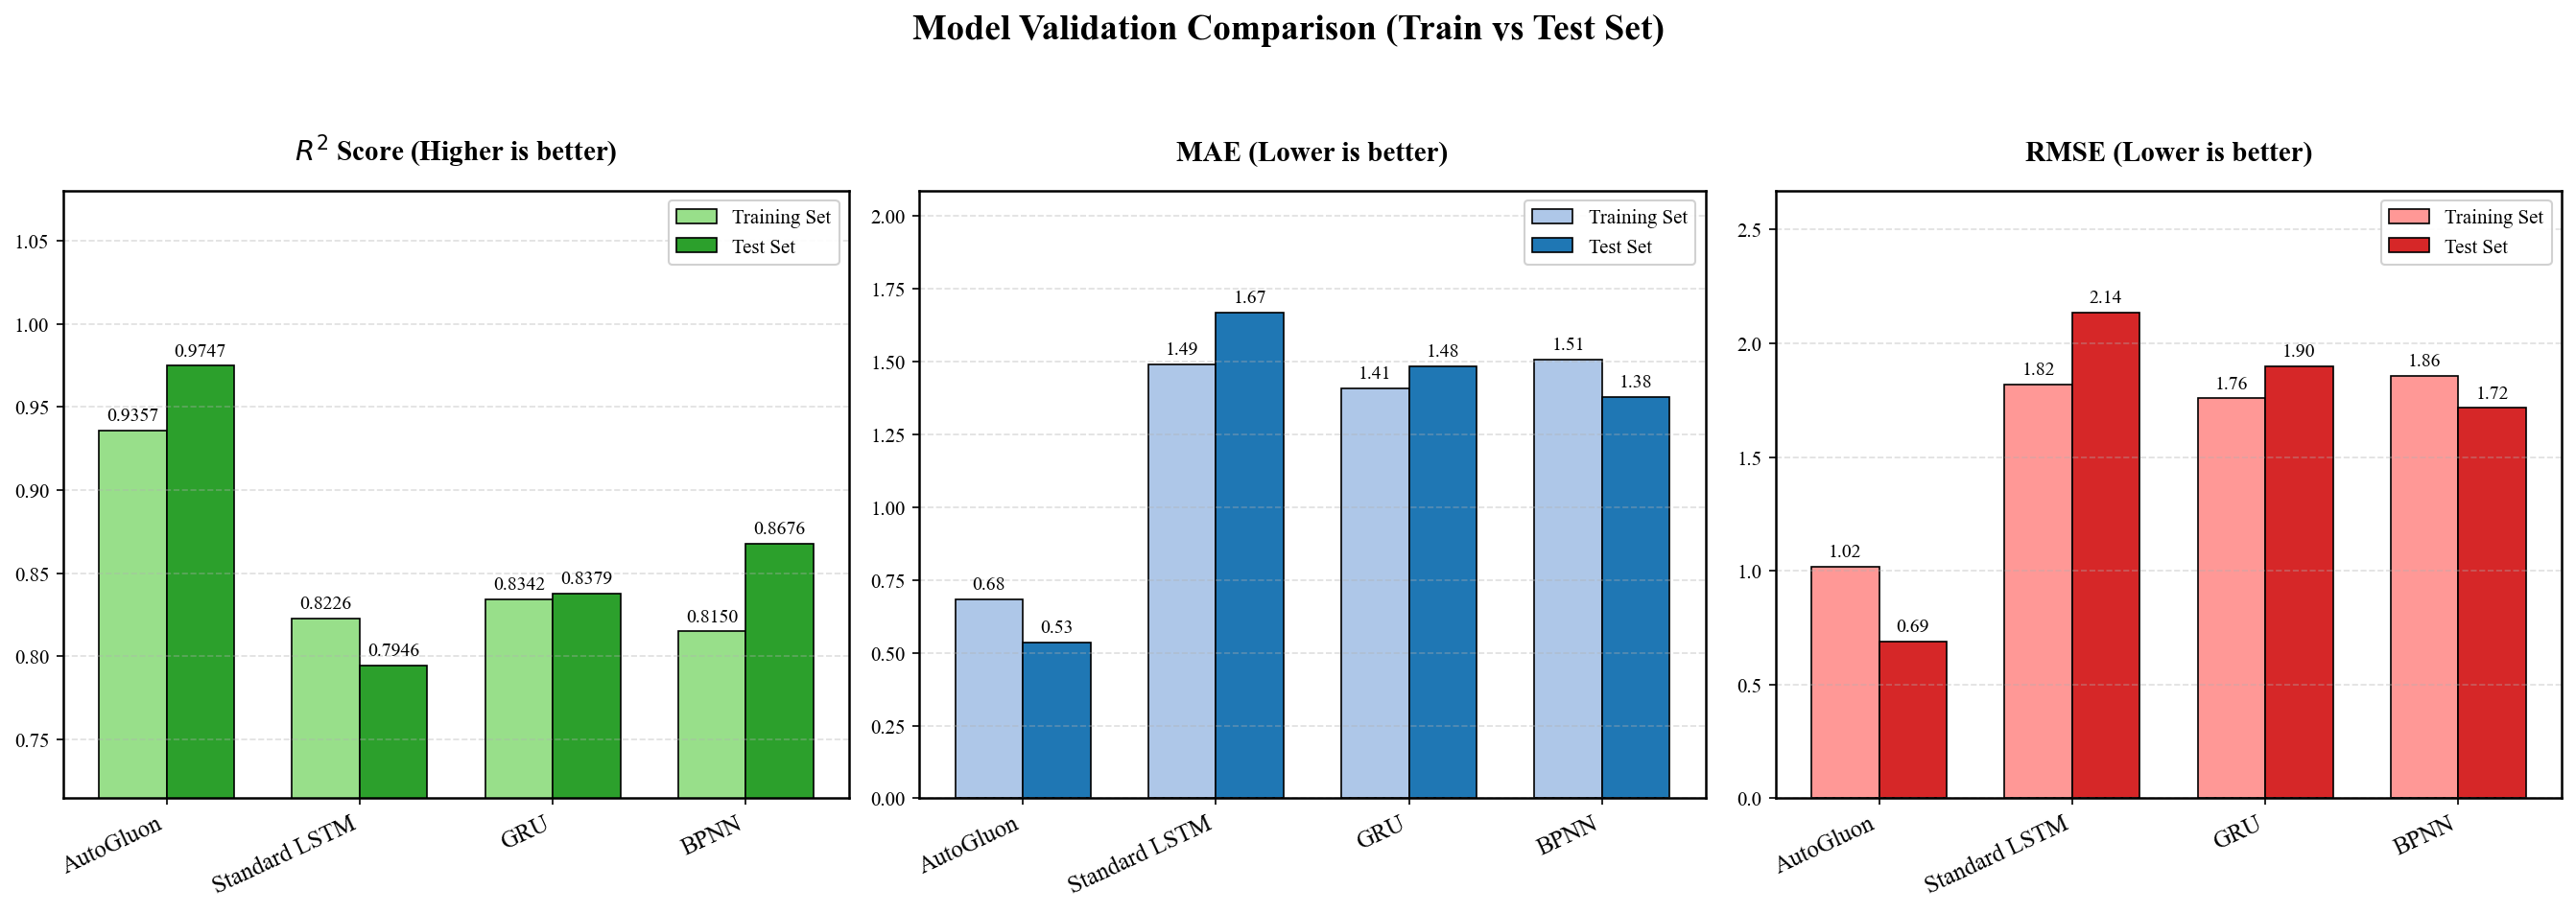

✅ 图表已保存为 Chart1_Model_Validation_Grouped.png

📊 Calculating Metrics for Engineering Validation Comparison (Train vs Blind Set) (Train vs Group 8)...


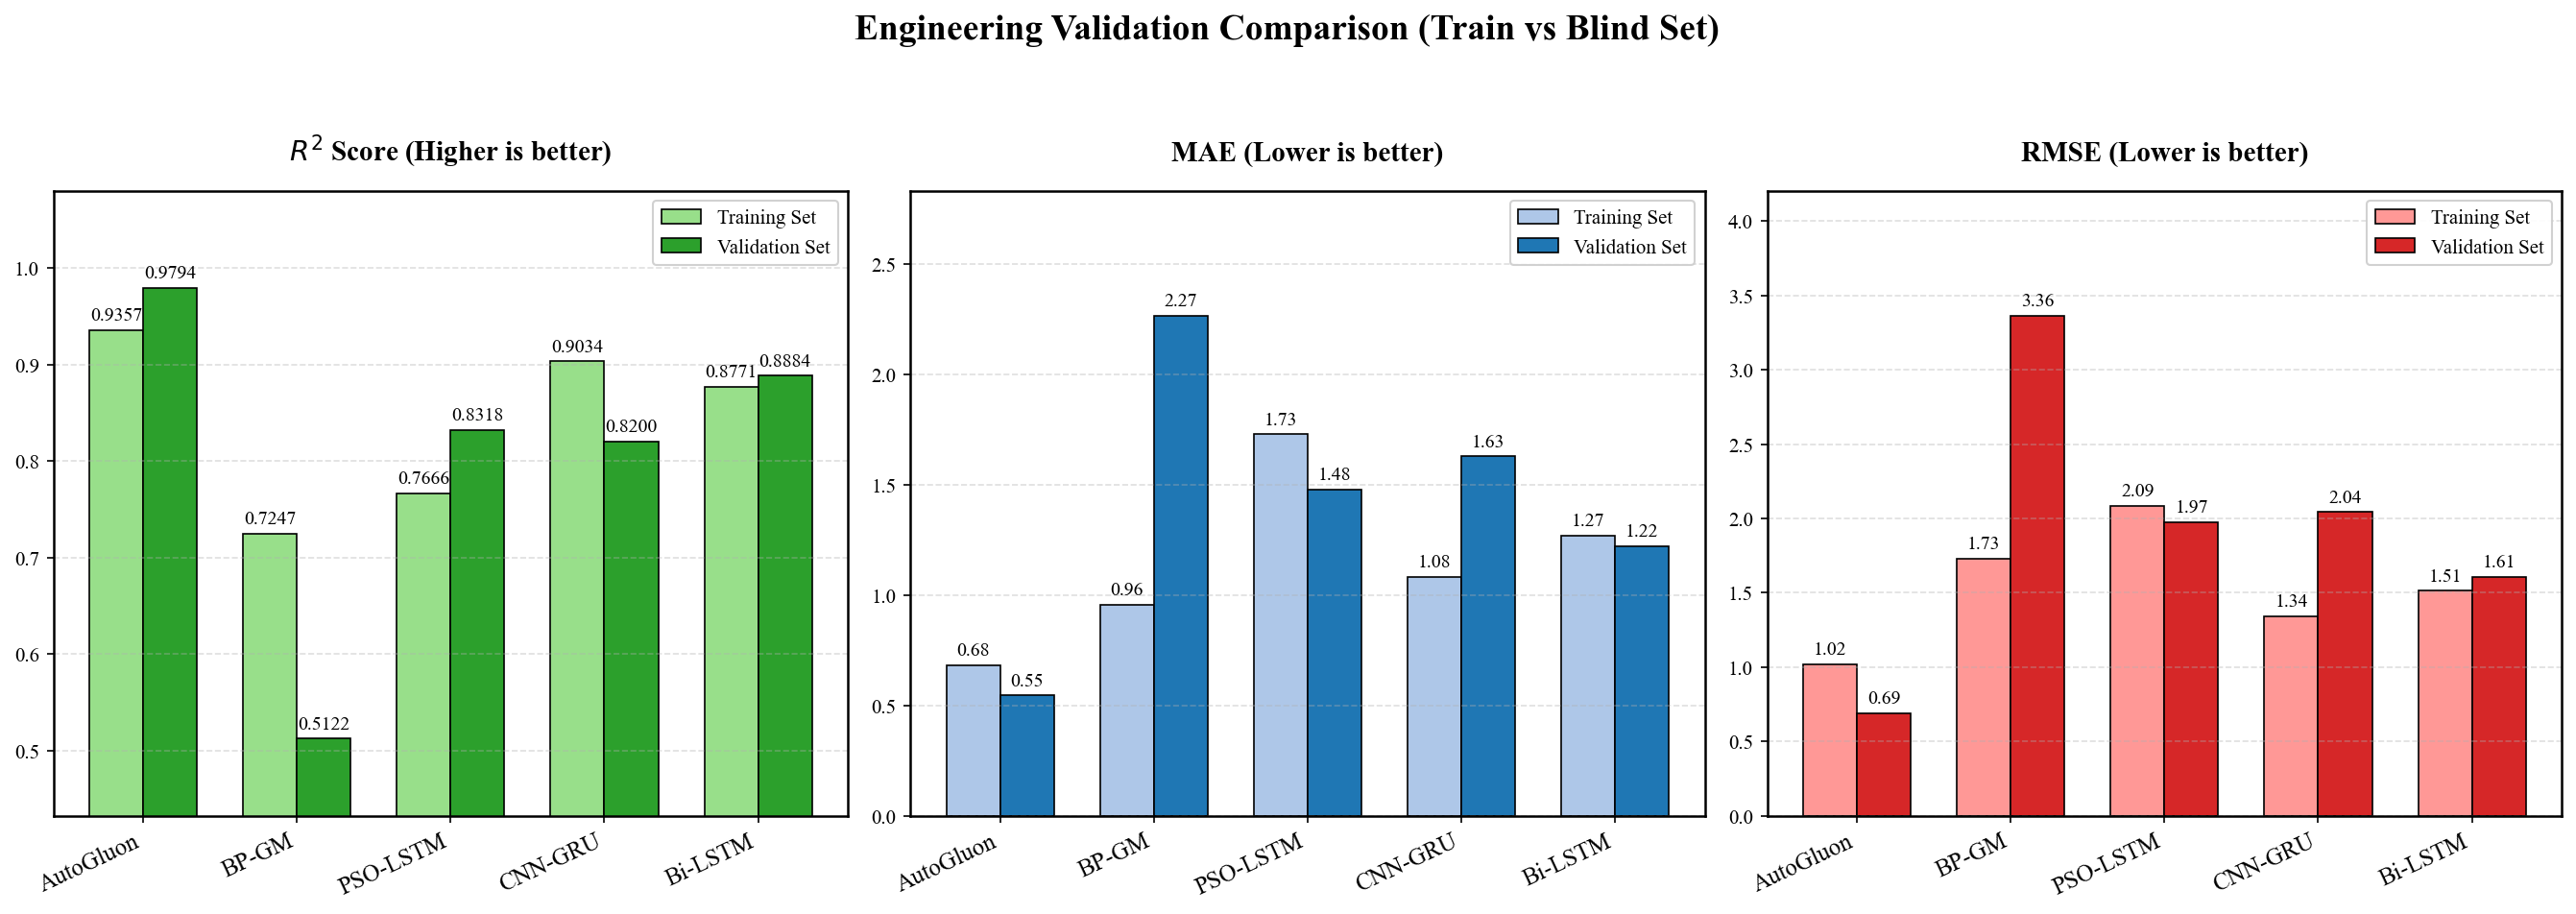

✅ 图表已保存为 Chart2_Engineering_Validation_Grouped.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import warnings

# ==========================================
# 0. 🎨 全局配置 (严格复刻 SCI 风格)
# ==========================================
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 任务分组字典
# ==========================================
# 任务1：模型验证 (基于第7组)
MODEL_VAL_MAP = {
    'AutoGluon': '02.csv',
    'Standard LSTM': '12.csv',
    'GRU': '13.csv',
    'BPNN': '14.csv'
}

# 任务2：工程验证 (基于第8组)
ENG_VAL_MAP = {
    'AutoGluon': '02.csv',
    'BP-GM': '15.csv',
    'PSO-LSTM': '16.csv',
    'CNN-GRU': '17.csv',
    'Bi-LSTM': '18.csv'"
}
REAL_DATA_PATH = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"

# ==========================================
# 2. 动态获取测点总数 (用于解决序列长度不一的问题)
# ==========================================
print("📂 Loading original Excel to determine total IDs...")
if not os.path.exists(REAL_DATA_PATH):
    raise ValueError(f"❌ 找不到原始数据文件: {REAL_DATA_PATH}")

all_sheets = pd.read_excel(REAL_DATA_PATH, sheet_name=None)
data_list = []
for i, sheet in enumerate(all_sheets.values()):
    sheet.columns = [str(c).strip() for c in sheet.columns]
    id_col = next((c for c in sheet.columns if '编号' in c), None)
    cum_col = next((c for c in sheet.columns if '累计' in c), None)
    if id_col and cum_col:
        temp = sheet[[id_col, cum_col]].copy()
        temp['TimeStep'] = i + 1
        data_list.append(temp)

df_true = pd.concat(data_list)
NUM_IDS = len(df_true[df_true['TimeStep'] == 7])
print(f"✅ 检测到有效测点数量: {NUM_IDS} 个。")

# ==========================================
# 3. 核心计算与【分组柱状图】绘图函数
# ==========================================
def generate_grouped_comparison_chart(file_map, target_group, chart_title, save_name):
    target_label = "Test" if target_group == 7 else "Validation"
    print(f"\n📊 Calculating Metrics for {chart_title} (Train vs Group {target_group})...")
    
    results = []
    for model_name, file_name in file_map.items():
        if os.path.exists(file_name):
            df_pred = pd.read_csv(file_name)
            
            # 智能赋予 TimeStep 标签
            if len(df_pred) == NUM_IDS * 3:
                df_pred['TimeStep'] = [6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 7:
                df_pred['TimeStep'] = [2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 8:
                df_pred['TimeStep'] = [1, 2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            else:
                print(f"  ⚠️ 警告: {model_name} 行数异常, 跳过。")
                continue

            # 提取训练集 (TimeStep <= 6)
            train_df = df_pred[(df_pred['TimeStep'] <= 6) & (df_pred['TimeStep'] > 0)]
            # 提取测试/验证集 (TimeStep == 7 or 8)
            target_df = df_pred[df_pred['TimeStep'] == target_group]
            
            if target_df.empty or train_df.empty:
                print(f"  ⚠️ 警告: {model_name} 数据提取失败。")
                continue
                
            # 计算训练集指标
            tr_r2 = r2_score(train_df['Actual'], train_df['Pred'])
            tr_mae = mean_absolute_error(train_df['Actual'], train_df['Pred'])
            tr_rmse = np.sqrt(mean_squared_error(train_df['Actual'], train_df['Pred']))
            
            # 计算目标集指标
            tg_r2 = r2_score(target_df['Actual'], target_df['Pred'])
            tg_mae = mean_absolute_error(target_df['Actual'], target_df['Pred'])
            tg_rmse = np.sqrt(mean_squared_error(target_df['Actual'], target_df['Pred']))
            
            results.append({
                'Model': model_name, 
                'Train_R2': tr_r2, 'Target_R2': tg_r2,
                'Train_MAE': tr_mae, 'Target_MAE': tg_mae,
                'Train_RMSE': tr_rmse, 'Target_RMSE': tg_rmse
            })
        else:
            print(f"  ⚠️ 找不到 {file_name} ({model_name})，跳过。")

    df_metrics = pd.DataFrame(results)
    if df_metrics.empty:
        print(f"❌ 未能生成 {chart_title}。")
        return

    # --- 开始绘制 1x3 分组柱状图 ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)
    
    # 颜色配置 (浅色=Train, 深色=Target)
    color_scheme = {
        'R2':   ('#98df8a', '#2ca02c'), # 浅绿, 深绿
        'MAE':  ('#aec7e8', '#1f77b4'), # 浅蓝, 深蓝
        'RMSE': ('#ff9896', '#d62728')  # 浅红, 深红
    }
    titles = ['$R^2$ Score (Higher is better)', 'MAE (Lower is better)', 'RMSE (Lower is better)']
    metric_keys = ['R2', 'MAE', 'RMSE']

    x_labels = df_metrics['Model'].tolist()
    x = np.arange(len(x_labels))
    width = 0.35 # 柱子宽度

    for i, metric in enumerate(metric_keys):
        ax = axes[i]
        c_train, c_target = color_scheme[metric]
        
        y_train = df_metrics[f'Train_{metric}'].values
        y_target = df_metrics[f'Target_{metric}'].values
        
        # 绘制训练集和目标集柱子
        rects1 = ax.bar(x - width/2, y_train, width, label='Training Set', color=c_train, edgecolor='black', linewidth=0.8)
        rects2 = ax.bar(x + width/2, y_target, width, label=f'{target_label} Set', color=c_target, edgecolor='black', linewidth=0.8)
        
        # 添加顶部数值标签
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                fmt = f'{height:.4f}' if metric == 'R2' else f'{height:.2f}'
                offset = height * 0.02 if metric != 'R2' else 0.005
                ax.annotate(fmt,
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),  # 垂直偏移
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9.5, family='Times New Roman', rotation=0)
        
        autolabel(rects1)
        autolabel(rects2)
        
        # 细节美化
        ax.set_title(titles[i], fontsize=14, fontweight='bold', pad=15)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=25, ha='right', fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
        ax.legend(loc='best', framealpha=0.9)
        
        # Y 轴范围动态适应
        if metric == 'R2':
            min_r2 = max(0.0, min(np.min(y_train), np.min(y_target)) - 0.08)
            ax.set_ylim(min_r2, 1.08) # 顶部留出空间写字
        else:
            ax.set_ylim(0, max(np.max(y_train), np.max(y_target)) * 1.25)
            
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)
            spine.set_color('black')

    plt.suptitle(chart_title, fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight')
    plt.show()
    print(f"✅ 图表已保存为 {save_name}")

# ==========================================
# 4. 运行生成两张大图
# ==========================================
# 第一张：模型验证 (Group 1~6 vs Group 7)
generate_grouped_comparison_chart(
    file_map=MODEL_VAL_MAP, 
    target_group=7, 
    chart_title="Model Validation Comparison (Train vs Test Set)", 
    save_name="Chart1_Model_Validation_Grouped.png"
)

# 第二张：工程验证 (Group 1~6 vs Group 8)
generate_grouped_comparison_chart(
    file_map=ENG_VAL_MAP, 
    target_group=8, 
    chart_title="Engineering Validation Comparison (Train vs Blind Set)", 
    save_name="Chart2_Engineering_Validation_Grouped.png"
)


📂 Loading original Excel to determine total IDs...
✅ 检测到有效测点数量: 81 个。将执行智能对齐...

📊 Extracting Error Data for Model Validation: Error Distribution Comparison (Group 7) (Group 7)...


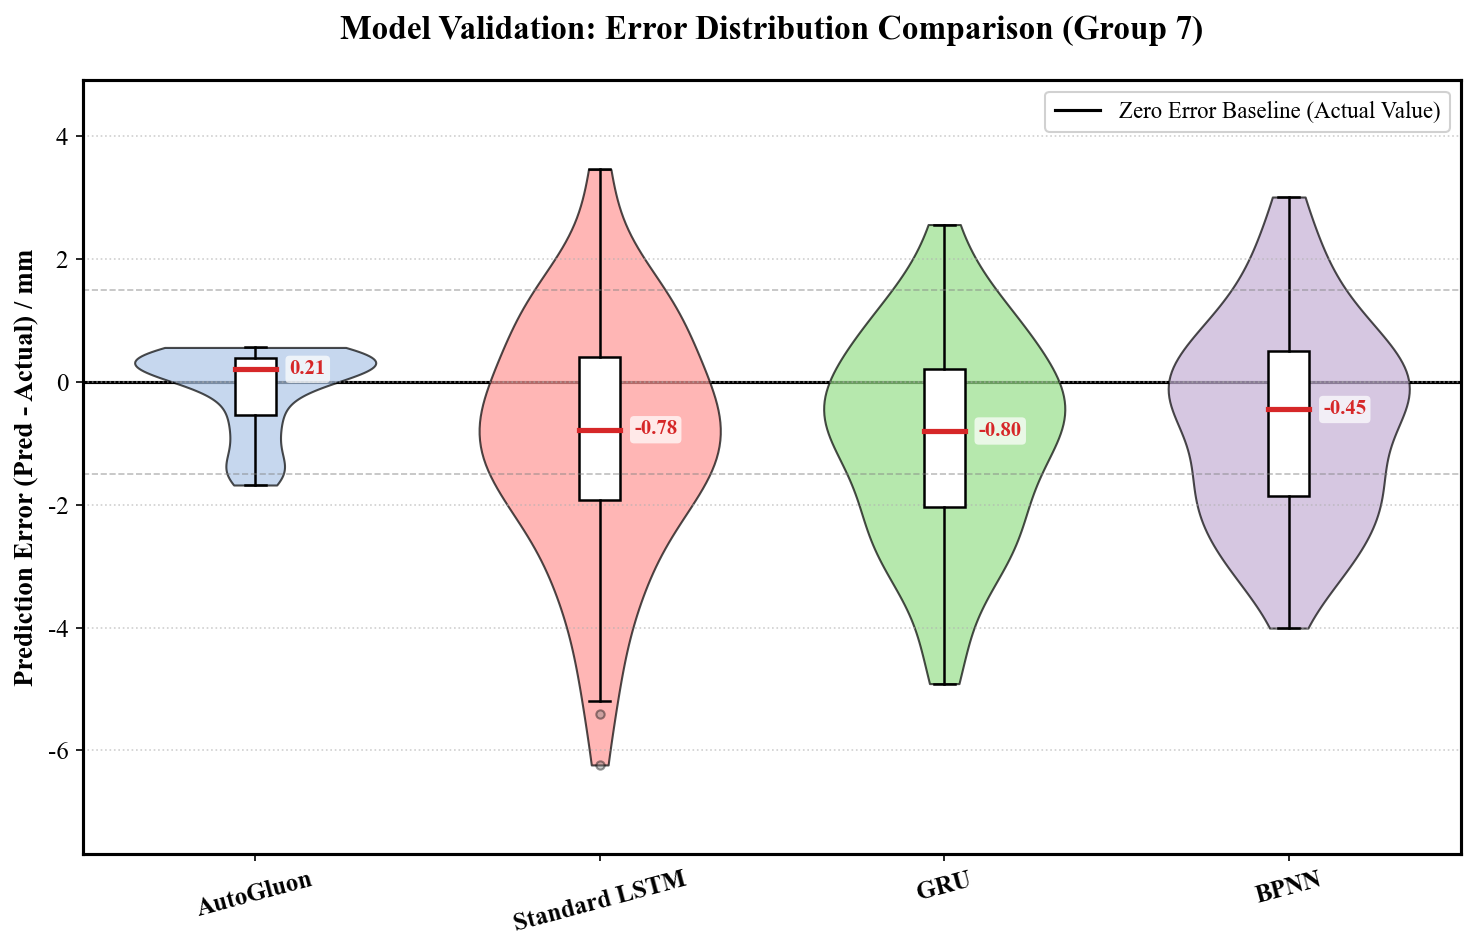

✅ 图表已保存为 Violin1_Advanced_Model_Val.png

📊 Extracting Error Data for Engineering Validation: Error Distribution Comparison (Group 8) (Group 8)...


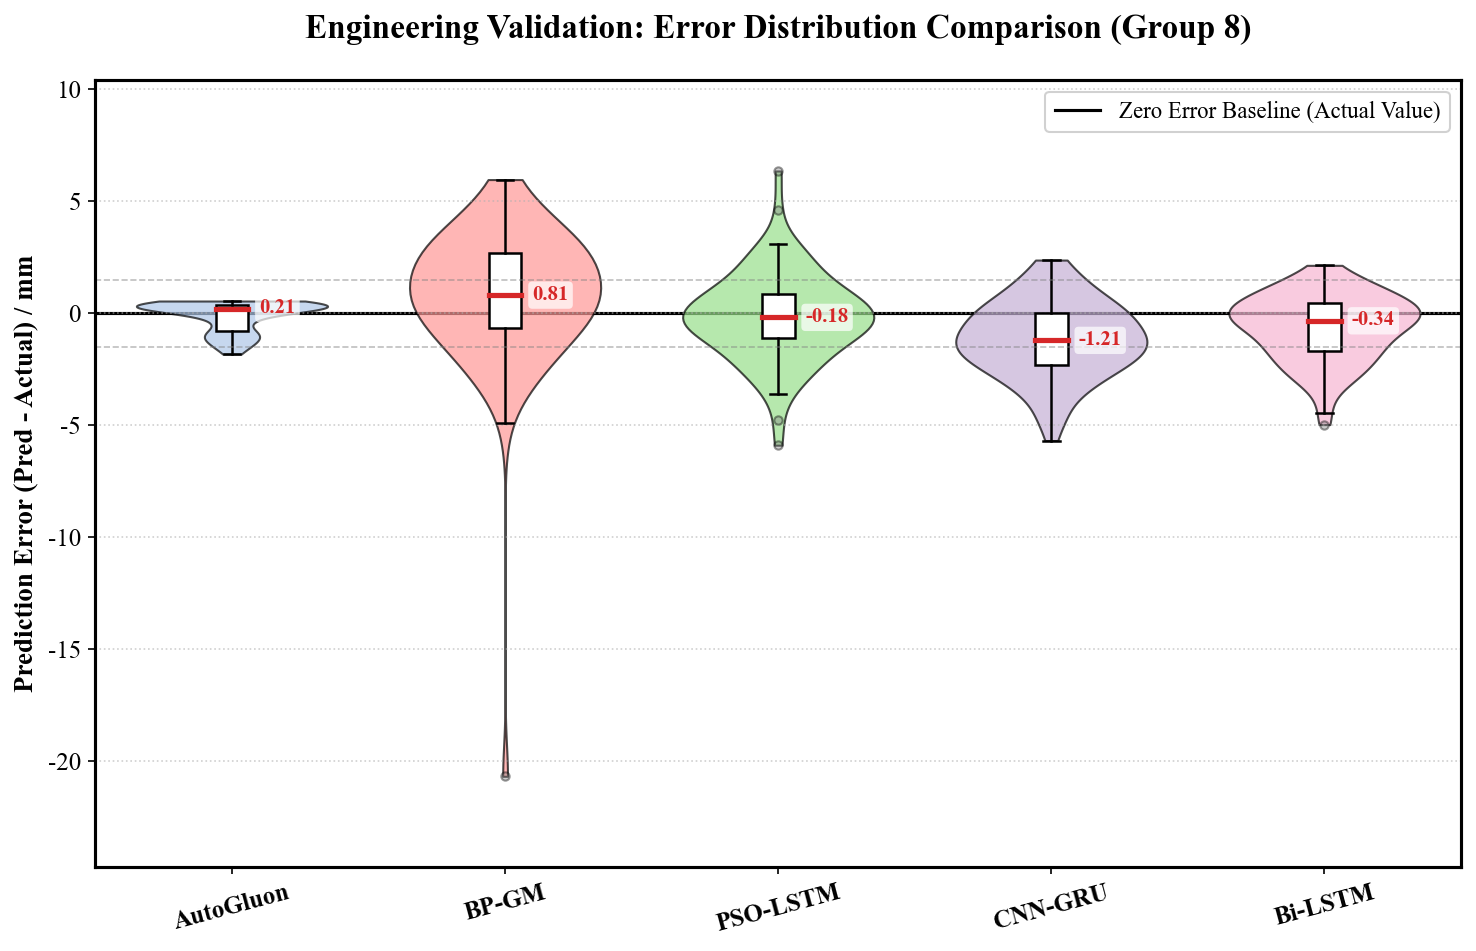

✅ 图表已保存为 Violin2_Advanced_Eng_Val.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

# ==========================================
# 0. 🎨 全局配置 (SCI 顶级期刊标准)
# ==========================================
warnings.filterwarnings('ignore')
# 确保使用 Times New Roman
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 任务分组字典
# ==========================================
# 任务1：模型验证 (基于第7组)
MODEL_VAL_MAP = {
    'AutoGluon': '02.csv',
    'Standard LSTM': '12.csv',
    'GRU': '13.csv',
    'BPNN': '14.csv'
}

# 任务2：工程验证 (基于第8组)
ENG_VAL_MAP = {
    'AutoGluon': '02.csv',
    'BP-GM': '15.csv',
    'PSO-LSTM': '16.csv',
    'CNN-GRU': '17.csv',
    'Bi-LSTM': '18.csv'"
}
REAL_DATA_PATH = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"

# 高级莫兰迪色系
COLOR_PALETTE = [
    '#aec7e8', '#ff9896', '#98df8a', '#c5b0d5', 
    '#f7b6d2', '#ffbb78', '#dbdb8d', '#c49c94'
]

# ==========================================
# 2. 动态获取测点总数
# ==========================================
print("📂 Loading original Excel to determine total IDs...")
if not os.path.exists(REAL_DATA_PATH):
    raise ValueError(f"❌ 找不到原始数据文件: {REAL_DATA_PATH}")

all_sheets = pd.read_excel(REAL_DATA_PATH, sheet_name=None)
data_list = []
for i, sheet in enumerate(all_sheets.values()):
    sheet.columns = [str(c).strip() for c in sheet.columns]
    id_col = next((c for c in sheet.columns if '编号' in c), None)
    cum_col = next((c for c in sheet.columns if '累计' in c), None)
    if id_col and cum_col:
        temp = sheet[[id_col, cum_col]].copy()
        temp['TimeStep'] = i + 1
        data_list.append(temp)

df_true = pd.concat(data_list)
NUM_IDS = len(df_true[df_true['TimeStep'] == 7])
print(f"✅ 检测到有效测点数量: {NUM_IDS} 个。将执行智能对齐...")

# ==========================================
# 3. 核心计算与【高级小提琴图】绘制函数
# ==========================================
def generate_advanced_violin_chart(file_map, target_group, chart_title, save_name):
    print(f"\n📊 Extracting Error Data for {chart_title} (Group {target_group})...")
    
    error_data = []
    model_labels = []
    
    for model_name, file_name in file_map.items():
        if os.path.exists(file_name):
            df_pred = pd.read_csv(file_name)
            
            # 智能赋予 TimeStep 标签
            if len(df_pred) == NUM_IDS * 3:
                df_pred['TimeStep'] = [6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 7:
                df_pred['TimeStep'] = [2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 8:
                df_pred['TimeStep'] = [1, 2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            else:
                continue

            group_df = df_pred[df_pred['TimeStep'] == target_group]
            if group_df.empty:
                continue
            
            # 误差计算: Pred - Actual
            errors = group_df['Pred'] - group_df['Actual']
            error_data.append(errors.values)
            model_labels.append(model_name)

    if not error_data:
        print(f"❌ 未能生成 {chart_title}，没有有效的数据。")
        return

    # --- 绘图开始 ---
    # 动态调整画布宽度，模型多就宽一点
    fig_width = max(10, len(model_labels) * 1.8)
    plt.figure(figsize=(fig_width, 6.5), dpi=150)
    ax = plt.gca()
    
    positions = np.arange(1, len(model_labels) + 1)
    
    # 1. 绘制小提琴主体
    violin_parts = ax.violinplot(
        error_data, positions=positions, 
        showmeans=False, showmedians=False, showextrema=False, widths=0.7
    )
    
    for i, pc in enumerate(violin_parts['bodies']):
        pc.set_facecolor(COLOR_PALETTE[i % len(COLOR_PALETTE)])
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

    # 2. 绘制内嵌箱线图
    bp = ax.boxplot(
        error_data, positions=positions, widths=0.12, patch_artist=True,
        showfliers=True, 
        flierprops=dict(marker='o', markersize=4, alpha=0.4, markeredgecolor='black', markerfacecolor='gray'),
        boxprops=dict(facecolor='white', color='black', linewidth=1.2),
        capprops=dict(color='black', linewidth=1.2),
        whiskerprops=dict(color='black', linewidth=1.2),
        medianprops=dict(color='#d62728', linewidth=2.5) # 加粗红色中位线
    )

    # 3. 🔴 核心优化：标注中位数数值
    for i, line in enumerate(bp['medians']):
        # 获取中位线的 Y 坐标
        median_y = line.get_ydata()[0]
        # 在中位线右侧一点点标注具体数字
        ax.text(positions[i] + 0.1, median_y, f'{median_y:.2f}', 
                verticalalignment='center', color='#d62728', 
                fontsize=10, fontweight='bold', family='Times New Roman',
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.7))

    # 4. 🔴 核心优化：强调真实值 (Zero Error Baseline)
    ax.axhline(0, color='black', linestyle='-', linewidth=1.5, zorder=0, label='Zero Error Baseline (Actual Value)')
    # 加两条浅色的辅助预警线 (±2mm 或 ±1mm，根据需要可调)
    ax.axhline(1.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.axhline(-1.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

    # 5. 整体布局美化
    ax.set_title(chart_title, fontsize=16, fontweight='bold', pad=20, family='Times New Roman')
    ax.set_ylabel('Prediction Error (Pred - Actual) / mm', fontsize=13, fontweight='bold', family='Times New Roman')
    
    ax.set_xticks(positions)
    # X 轴标签加粗并稍微倾斜，防拥挤
    ax.set_xticklabels(model_labels, fontsize=12, fontweight='bold', family='Times New Roman', rotation=15)
    
    ax.legend(loc='upper right', framealpha=0.9, prop={'family': 'Times New Roman', 'size': 11})
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    
    # 动态 Y 轴：给顶部和底部留出 15% 的空间
    y_min = min([np.min(d) for d in error_data])
    y_max = max([np.max(d) for d in error_data])
    padding = (y_max - y_min) * 0.15
    ax.set_ylim(y_min - padding, y_max + padding)
    
    # 黑色加粗边框
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight')
    plt.show()
    print(f"✅ 图表已保存为 {save_name}")

# ==========================================
# 4. 运行生成两张大图
# ==========================================
generate_advanced_violin_chart(
    file_map=MODEL_VAL_MAP, 
    target_group=7, 
    chart_title="Model Validation: Error Distribution Comparison (Group 7)", 
    save_name="Violin1_Advanced_Model_Val.png"
)

generate_advanced_violin_chart(
    file_map=ENG_VAL_MAP, 
    target_group=8, 
    chart_title="Engineering Validation: Error Distribution Comparison (Group 8)", 
    save_name="Violin2_Advanced_Eng_Val.png"
)

📂 Loading original Excel to determine total IDs...
✅ 检测到有效测点数量: 81 个。将执行智能对齐...

📊 Extracting Error Data for Model Validation: Error Density Facet Plot (Group 7) (Group 7)...


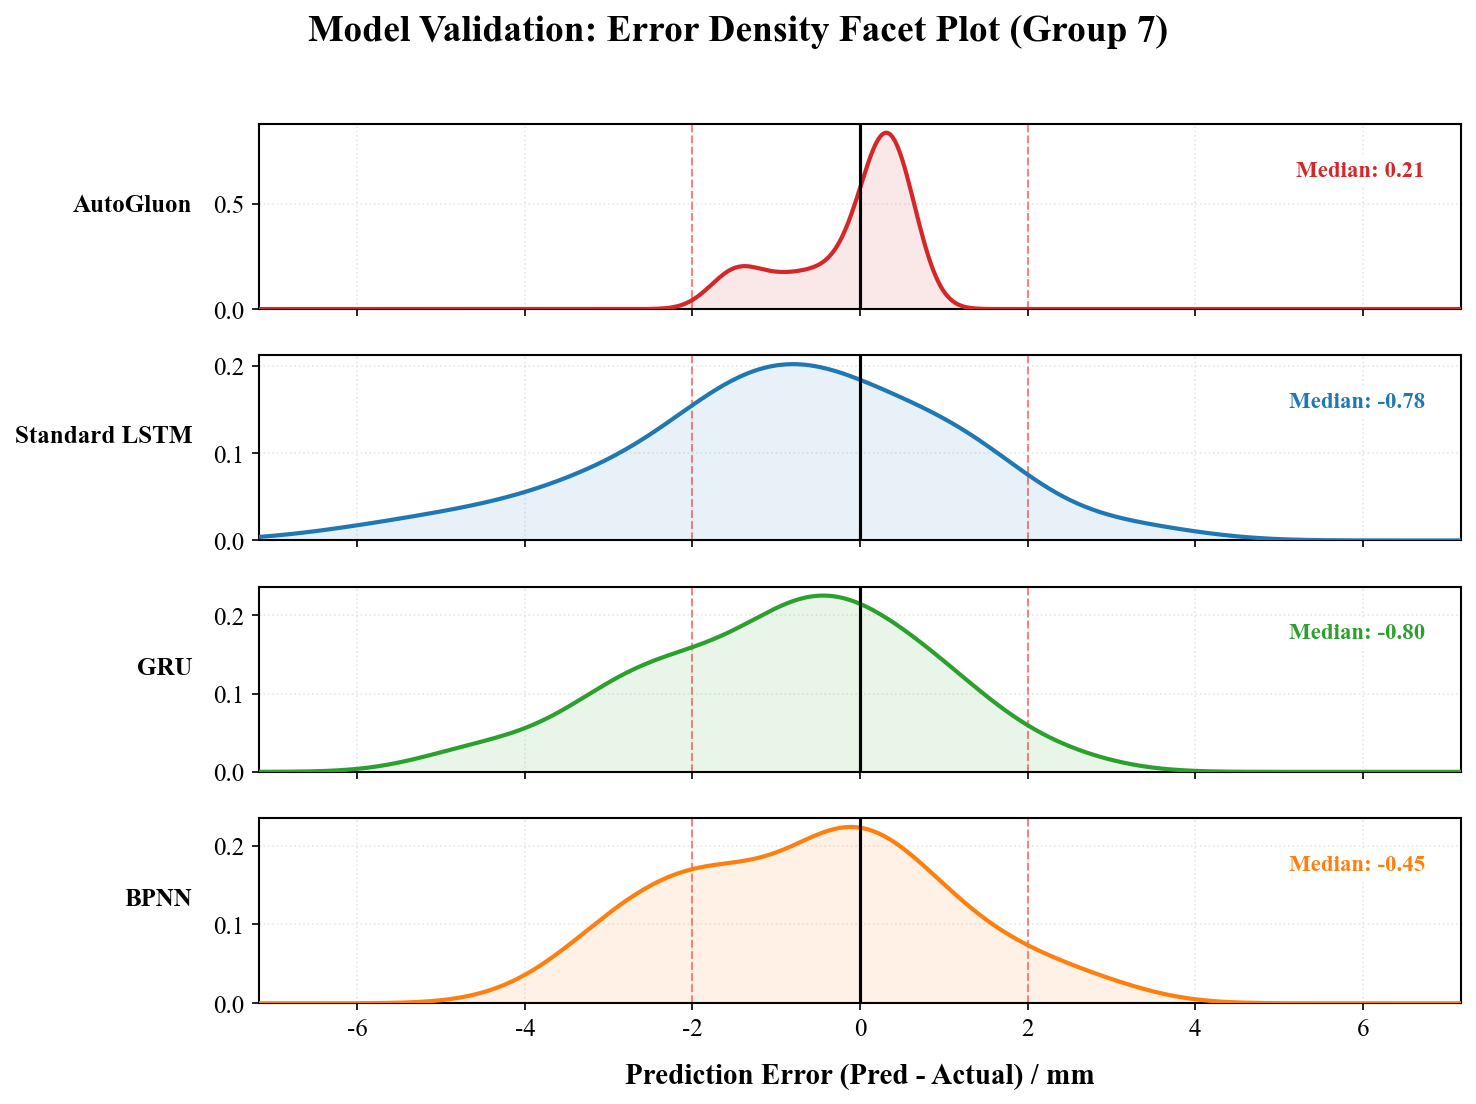

✅ 垂直KDE图已保存为 SCI_Facet_KDE1_Model_Val.png

📊 Extracting Error Data for Engineering Validation: Error Density Facet Plot (Group 8) (Group 8)...


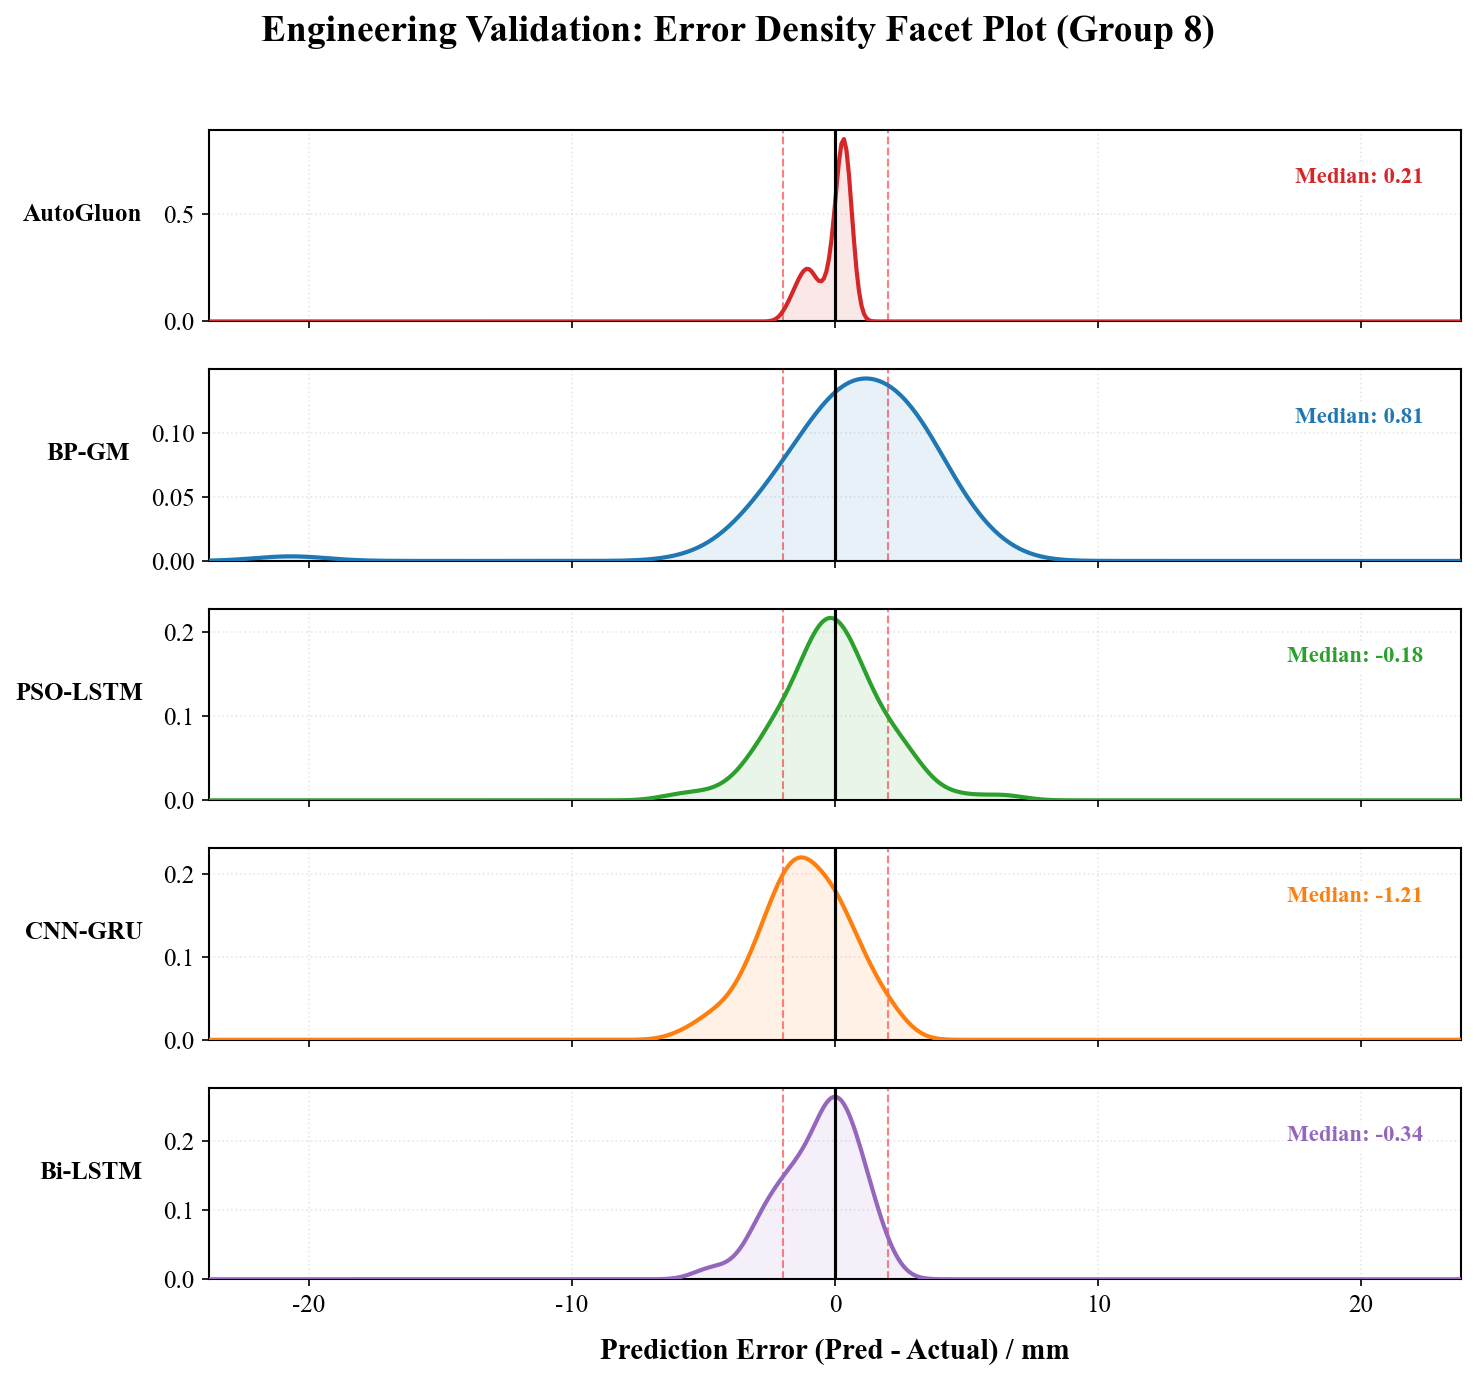

✅ 垂直KDE图已保存为 SCI_Facet_KDE2_Eng_Val.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os
import warnings

# ==========================================
# 0. 🎨 全局配置 (SCI 顶级期刊标准)
# ==========================================
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 任务分组字典
# ==========================================
# 任务1：模型验证 (基于第7组)
MODEL_VAL_MAP = {
    'AutoGluon': '02.csv',
    'Standard LSTM': '12.csv',
    'GRU': '13.csv',
    'BPNN': '14.csv'
}

# 任务2：工程验证 (基于第8组)
ENG_VAL_MAP = {
    'AutoGluon': '02.csv',
    'BP-GM': '15.csv',
    'PSO-LSTM': '16.csv',
    'CNN-GRU': '17.csv',
    'Bi-LSTM': '18.csv'"
}
REAL_DATA_PATH = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"

# 高级莫兰迪色系 (适配多子图)
COLOR_PALETTE = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']

# ==========================================
# 2. 动态获取测点总数
# ==========================================
print("📂 Loading original Excel to determine total IDs...")
if not os.path.exists(REAL_DATA_PATH):
    raise ValueError(f"❌ 找不到原始数据文件: {REAL_DATA_PATH}")

all_sheets = pd.read_excel(REAL_DATA_PATH, sheet_name=None)
data_list = []
for i, sheet in enumerate(all_sheets.values()):
    sheet.columns = [str(c).strip() for c in sheet.columns]
    id_col = next((c for c in sheet.columns if '编号' in c), None)
    cum_col = next((c for c in sheet.columns if '累计' in c), None)
    if id_col and cum_col:
        temp = sheet[[id_col, cum_col]].copy()
        temp['TimeStep'] = i + 1
        data_list.append(temp)

df_true = pd.concat(data_list)
NUM_IDS = len(df_true[df_true['TimeStep'] == 7])
print(f"✅ 检测到有效测点数量: {NUM_IDS} 个。将执行智能对齐...")

# ==========================================
# 3. 核心绘图函数 (方案二：垂直多子图 KDE)
# ==========================================
def generate_scipy_facet_kde(file_map, target_group, chart_title, save_name):
    print(f"\n📊 Extracting Error Data for {chart_title} (Group {target_group})...")
    
    error_data = {}
    for model_name, file_name in file_map.items():
        if os.path.exists(file_name):
            df_pred = pd.read_csv(file_name)
            
            # 智能对齐
            if len(df_pred) == NUM_IDS * 3:
                df_pred['TimeStep'] = [6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 7:
                df_pred['TimeStep'] = [2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 8:
                df_pred['TimeStep'] = [1, 2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            else:
                continue

            group_df = df_pred[df_pred['TimeStep'] == target_group]
            if group_df.empty: continue
            
            # 误差 = 预测 - 真实
            error_data[model_name] = (group_df['Pred'] - group_df['Actual']).values

    if not error_data:
        print("❌ 没有有效数据。")
        return

    # --- 开始绘制垂直多子图 ---
    num_models = len(error_data)
    # 动态画布高度
    fig_height = max(7, num_models * 1.8)
    # 🔴 关键：nrows=num_models, ncols=1，垂直排列
    fig, axes = plt.subplots(nrows=num_models, ncols=1, figsize=(10, fig_height), dpi=150, sharex=True)
    
    # 确保 axes 是一个列表
    if num_models == 1: axes = [axes]
    
    max_x_abs = 0 
    for err in error_data.values():
        max_x_abs = max(max_x_abs, np.max(np.abs(err)))
    
    # 统一 X 轴评估范围
    x_lim = max(max_x_abs * 1.15, 3.0)
    x_eval = np.linspace(-x_lim, x_lim, 500)

    for i, (model_name, errors) in enumerate(error_data.items()):
        ax = axes[i]
        c = COLOR_PALETTE[i % len(COLOR_PALETTE)]
        
        # 1. 计算 KDE 和中位数
        kde = gaussian_kde(errors)
        y_eval = kde(x_eval)
        median_err = np.median(errors)
        
        # 2. 绘制密度曲线和填充
        ax.plot(x_eval, y_eval, color=c, linewidth=2.0, zorder=3)
        ax.fill_between(x_eval, y_eval, 0, color=c, alpha=0.1, zorder=2)
        
        # 3. 绘制每个小图的 0 误差垂直基准线
        ax.axvline(0, color='black', linestyle='-', linewidth=1.5, zorder=4)
        ax.axvline(2, color='red', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
        ax.axvline(-2, color='red', linestyle='--', linewidth=1, alpha=0.5, zorder=1)
        
        # 4. 在图右上角添加信息框标注中位数 (诊断系统偏误)
        median_label = f"Median: {median_err:.2f}"
        ax.text(0.97, 0.8, median_label, transform=ax.transAxes, 
                fontsize=11, family='Times New Roman', fontweight='bold', color=c,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'),
                ha='right', va='top')

        # 子图细节美化
        ax.set_ylabel(f"{model_name}", fontsize=12, fontweight='bold', family='Times New Roman', labelpad=10, rotation=0, ha='right')
        ax.set_ylim(bottom=0)
        ax.grid(axis='both', linestyle=':', alpha=0.3)
        
        # 边框加黑
        for spine in ax.spines.values():
            spine.set_linewidth(1.0)
            spine.set_color('black')

    # X 轴美化 (设置在最底层子图)
    axes[-1].set_xlabel('Prediction Error (Pred - Actual) / mm', fontsize=14, fontweight='bold', labelpad=10)
    axes[-1].set_xlim(-x_lim, x_lim)

    # 总体大标题
    plt.suptitle(chart_title, fontsize=18, fontweight='bold', y=1.02, family='Times New Roman')
    plt.tight_layout()
    # 减小各子图之间的间距，使对比更紧凑
    plt.subplots_adjust(hspace=0.25)
    
    plt.savefig(save_name, bbox_inches='tight')
    plt.show()
    print(f"✅ 垂直KDE图已保存为 {save_name}")

# ==========================================
# 4. 运行生成垂直多子图 KDE
# ==========================================
# 第一张：模型验证 (Group 7)
generate_scipy_facet_kde(
    file_map=MODEL_VAL_MAP, 
    target_group=7, 
    chart_title="Model Validation: Error Density Facet Plot (Group 7)", 
    save_name="SCI_Facet_KDE1_Model_Val.png"
)

# 第二张：工程验证 (Group 8)
generate_scipy_facet_kde(
    file_map=ENG_VAL_MAP, 
    target_group=8, 
    chart_title="Engineering Validation: Error Density Facet Plot (Group 8)", 
    save_name="SCI_Facet_KDE2_Eng_Val.png"
)

📂 Loading original Excel to determine total IDs...
✅ 检测到有效测点数量: 81 个。将执行智能对齐...

📊 Extracting Absolute Error Data for CDF Model Validation: Error Cumulative Distribution (Group 7) (Group 7)...


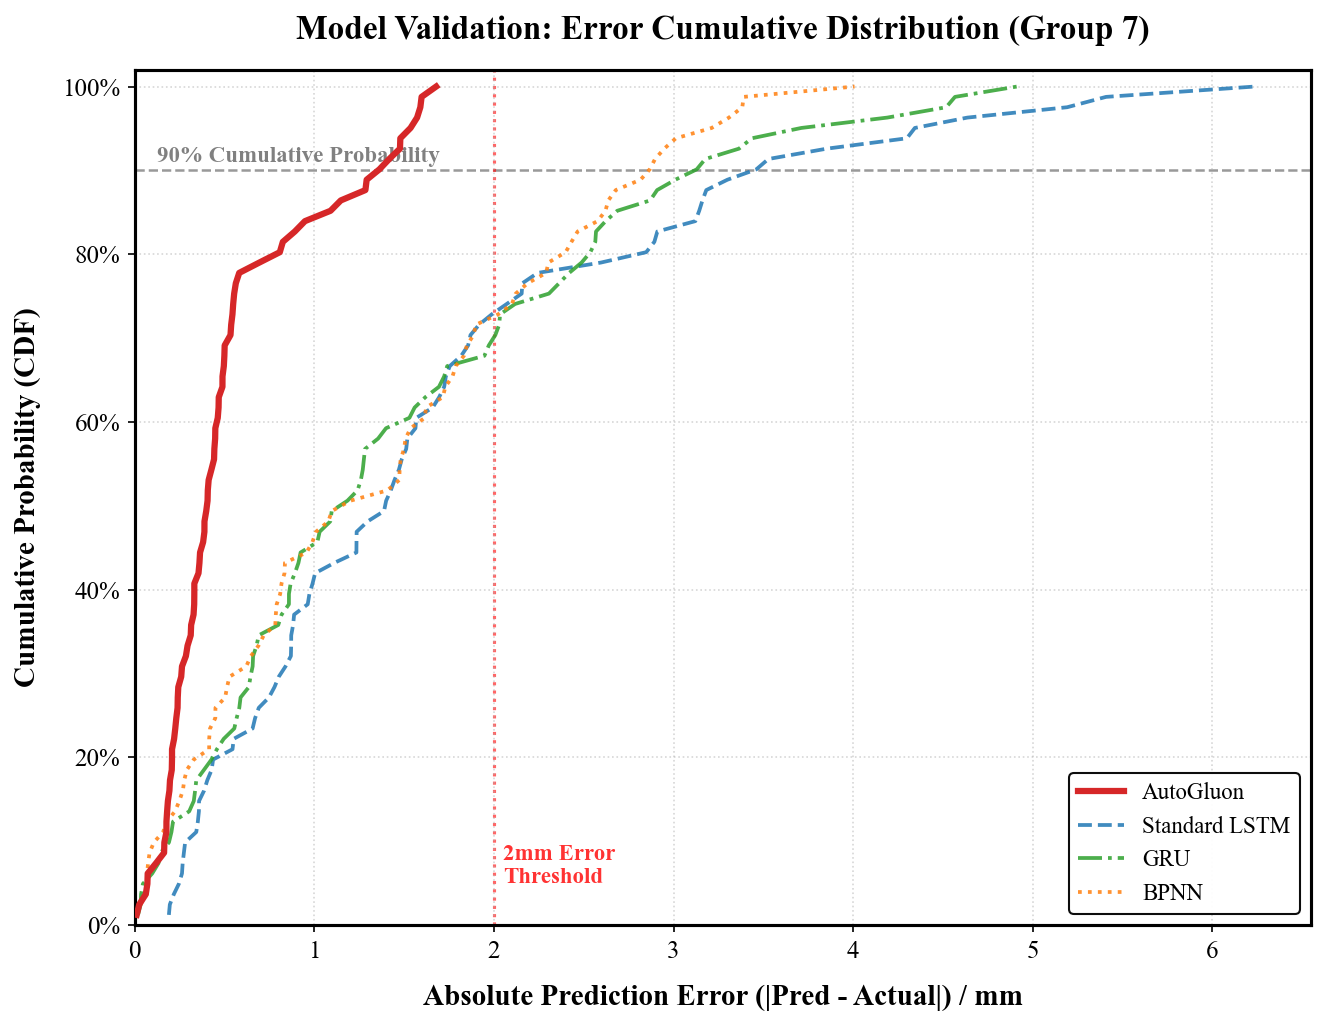

✅ CDF图已保存为 CDF1_Model_Validation.png

📊 Extracting Absolute Error Data for CDF Engineering Validation: Error Cumulative Distribution (Group 8) (Group 8)...


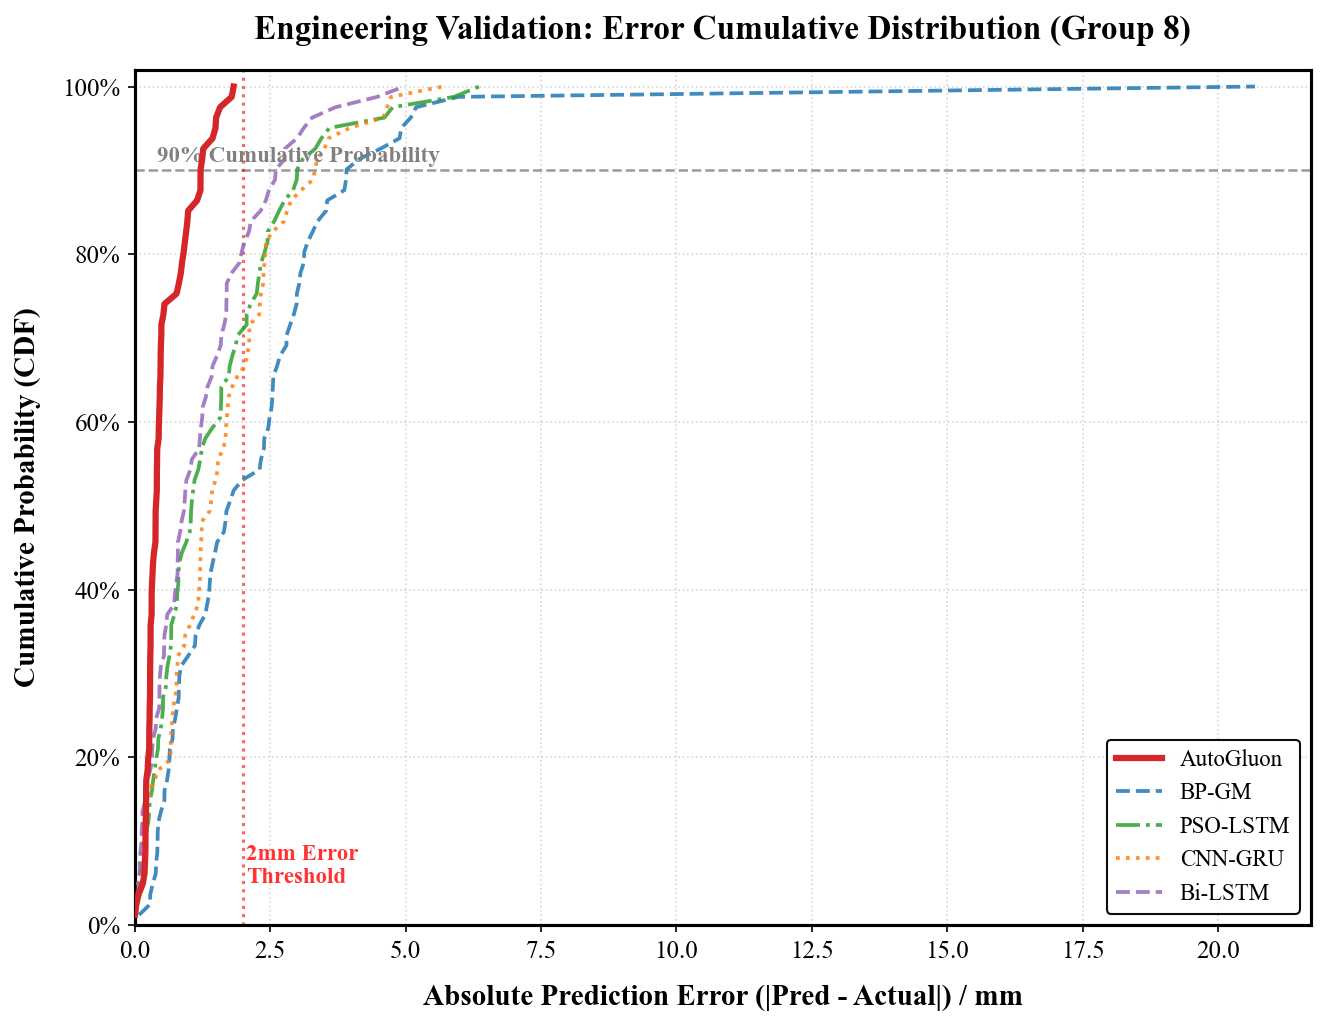

✅ CDF图已保存为 CDF2_Engineering_Validation.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import warnings

# ==========================================
# 0. 🎨 全局配置 (SCI 顶级期刊标准)
# ==========================================
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 任务分组字典
# ==========================================
# 任务1：模型验证 (基于第7组)
MODEL_VAL_MAP = {
    'AutoGluon': '02.csv',
    'Standard LSTM': '12.csv',
    'GRU': '13.csv',
    'BPNN': '14.csv'
}

# 任务2：工程验证 (基于第8组)
ENG_VAL_MAP = {
    'AutoGluon': '02.csv',
    'BP-GM': '15.csv',
    'PSO-LSTM': '16.csv',
    'CNN-GRU': '17.csv',
    'Bi-LSTM': '18.csv'"
}
REAL_DATA_PATH = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"


# 莫兰迪高辨识度配色
COLORS = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2']
LINESTYLES = ['--', '-.', ':', '--', '-.']

# ==========================================
# 2. 动态获取测点总数
# ==========================================
print("📂 Loading original Excel to determine total IDs...")
if not os.path.exists(REAL_DATA_PATH):
    raise ValueError(f"❌ 找不到原始数据文件: {REAL_DATA_PATH}")

all_sheets = pd.read_excel(REAL_DATA_PATH, sheet_name=None)
data_list = []
for i, sheet in enumerate(all_sheets.values()):
    sheet.columns = [str(c).strip() for c in sheet.columns]
    id_col = next((c for c in sheet.columns if '编号' in c), None)
    cum_col = next((c for c in sheet.columns if '累计' in c), None)
    if id_col and cum_col:
        temp = sheet[[id_col, cum_col]].copy()
        temp['TimeStep'] = i + 1
        data_list.append(temp)

df_true = pd.concat(data_list)
NUM_IDS = len(df_true[df_true['TimeStep'] == 7])
print(f"✅ 检测到有效测点数量: {NUM_IDS} 个。将执行智能对齐...")

# ==========================================
# 3. 核心绘图函数 (CDF 累积分布概率图)
# ==========================================
def generate_cdf_chart(file_map, target_group, chart_title, save_name):
    print(f"\n📊 Extracting Absolute Error Data for CDF {chart_title} (Group {target_group})...")
    
    error_data = {}
    for model_name, file_name in file_map.items():
        if os.path.exists(file_name):
            df_pred = pd.read_csv(file_name)
            
            # 智能对齐 TimeStep 标签
            if len(df_pred) == NUM_IDS * 3:
                df_pred['TimeStep'] = [6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 7:
                df_pred['TimeStep'] = [2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 8:
                df_pred['TimeStep'] = [1, 2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            else:
                continue

            group_df = df_pred[df_pred['TimeStep'] == target_group]
            if group_df.empty: continue
            
            # 🔴 核心计算：CDF 看的是【绝对误差】，不分正负方向，只看偏离大小
            abs_errors = np.abs(group_df['Pred'] - group_df['Actual']).values
            # 从小到大排序
            sorted_errors = np.sort(abs_errors)
            # 计算累积概率 P(X <= x)
            cdf_probs = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
            
            error_data[model_name] = (sorted_errors, cdf_probs)

    if not error_data:
        print(f"❌ 未能生成 {chart_title}，没有有效的数据。")
        return

    # --- 开始绘制 CDF 图 ---
    plt.figure(figsize=(9, 7), dpi=150)
    ax = plt.gca()

    max_x_err = 0 
    color_idx = 0

    for model_name, (sorted_errors, cdf_probs) in error_data.items():
        max_x_err = max(max_x_err, np.max(sorted_errors))
        
        # 🔴 为 AutoGluon 设置专属“冠军级”高亮外观
        if model_name == 'AutoGluon':
            c = '#d62728'      # 醒目的红色
            ls = '-'           # 坚实的实线
            lw = 3.0           # 极粗的线条
            z_level = 10       # 绝对置顶，不被遮挡
            alpha_val = 1.0
        else:
            c = COLORS[color_idx % len(COLORS)]
            ls = LINESTYLES[color_idx % len(LINESTYLES)]
            lw = 1.8
            z_level = 3
            alpha_val = 0.85
            color_idx += 1
            
        # 绘制梯形步进 CDF 曲线（更严谨的统计学画法）
        # 如果想让曲线平滑，可以把 drawstyle 去掉
        ax.plot(sorted_errors, cdf_probs, color=c, linestyle=ls, linewidth=lw, 
                alpha=alpha_val, label=model_name, zorder=z_level)

    # ================= 辅助工程解释线 =================
    # 1. 90% 累积置信度参考线
    ax.axhline(0.9, color='gray', linestyle='--', linewidth=1.2, alpha=0.8, zorder=1)
    ax.text(max_x_err * 0.02, 0.91, '90% Cumulative Probability', color='gray', fontsize=11, fontweight='bold')

    # 2. 2mm 绝对误差工程预警线
    ax.axvline(2.0, color='red', linestyle=':', linewidth=1.5, alpha=0.6, zorder=1)
    ax.text(2.05, 0.05, '2mm Error\nThreshold', color='red', fontsize=11, fontweight='bold', alpha=0.8)

    # 图表细节美化
    ax.set_title(chart_title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Absolute Prediction Error (|Pred - Actual|) / mm', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylabel('Cumulative Probability (CDF)', fontsize=14, fontweight='bold', labelpad=10)
    
    # 坐标轴范围与刻度
    ax.set_xlim(0, max(max_x_err * 1.05, 2.5)) # 保证包含 2mm 线
    ax.set_ylim(0, 1.02)
    
    # 将 Y 轴转换为百分比显示，更具工程直观性
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))
    
    # 图例设置 (放置在右下角，因为 CDF 曲线主要集中在左上角)
    ax.legend(loc='lower right', framealpha=0.95, edgecolor='black', fontsize=11, prop={'family': 'Times New Roman', 'size': 11})
    
    # 浅灰色网格
    ax.grid(axis='both', linestyle=':', alpha=0.5)
    
    # 四周边框加黑加粗
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

    plt.tight_layout()
    plt.savefig(save_name, bbox_inches='tight')
    plt.show()
    print(f"✅ CDF图已保存为 {save_name}")

# ==========================================
# 4. 运行生成两张大图
# ==========================================
# 第一张：模型验证 (Group 7)
generate_cdf_chart(
    file_map=MODEL_VAL_MAP, 
    target_group=7, 
    chart_title="Model Validation: Error Cumulative Distribution (Group 7)", 
    save_name="CDF1_Model_Validation.png"
)

# 第二张：工程验证 (Group 8)
generate_cdf_chart(
    file_map=ENG_VAL_MAP, 
    target_group=8, 
    chart_title="Engineering Validation: Error Cumulative Distribution (Group 8)", 
    save_name="CDF2_Engineering_Validation.png"
)

📂 Loading original Excel to determine total IDs...
✅ 检测到有效测点数量: 81 个。

📊 Extracting Error Data for Engineering Validation: Residual Fluctuation Curves (Blind Set - Group 8) (Group 8)...


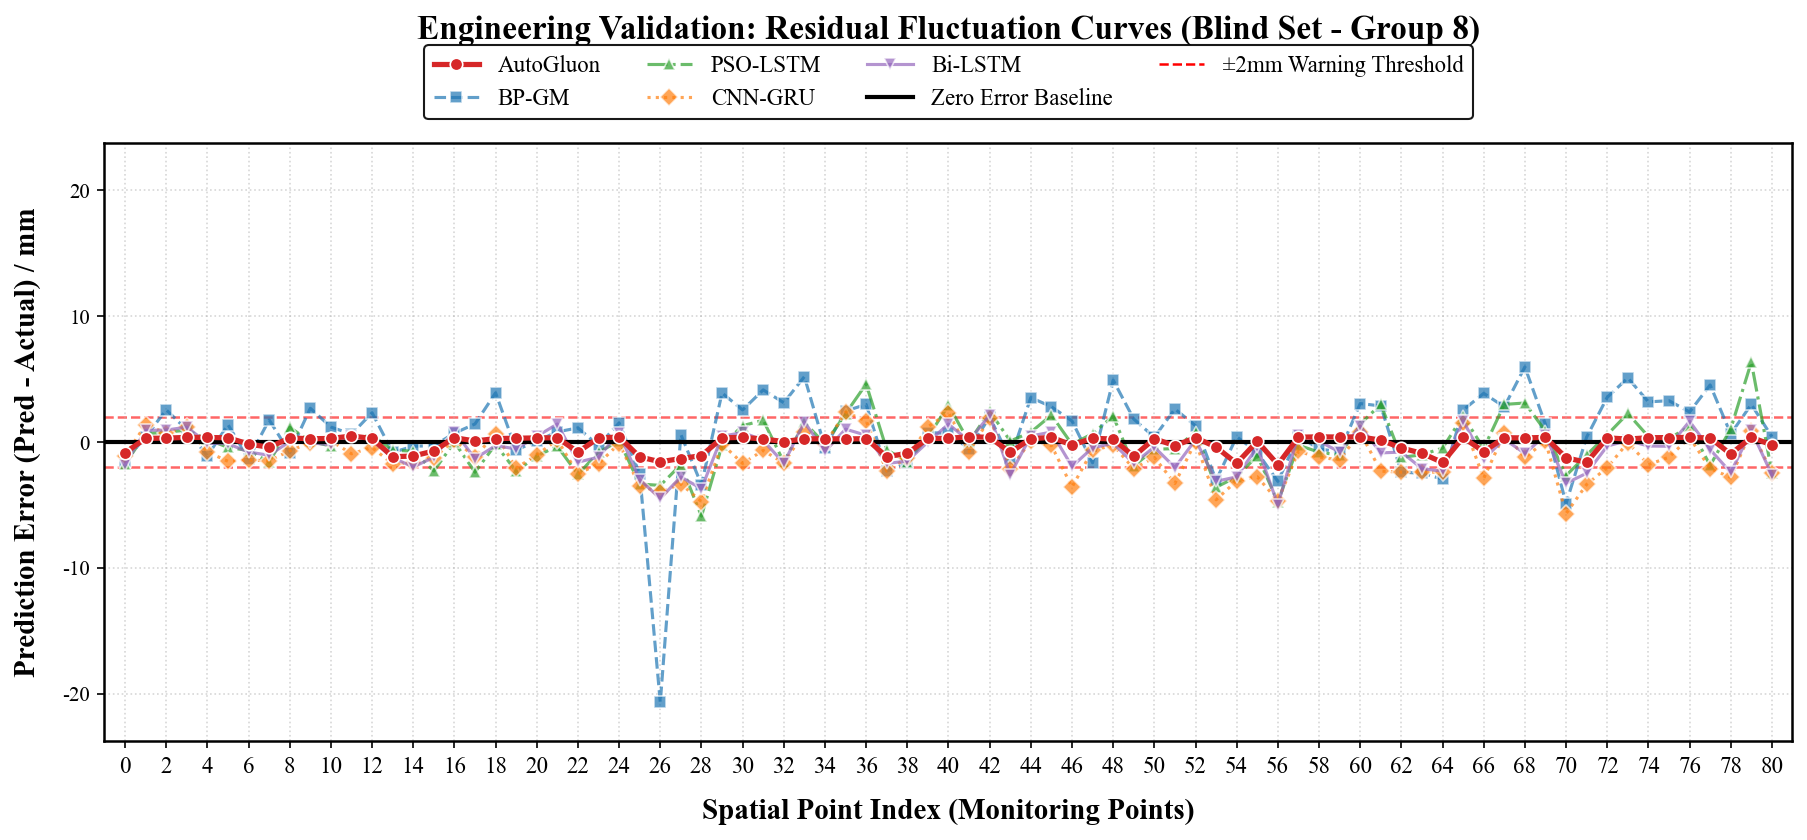

✅ 图表已保存为 Focused_LineChart2_Engineering_Validation_Residuals.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

# ==========================================
# 0. 🎨 全局配置 (SCI 顶级期刊标准)
# ==========================================
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 任务分组字典 (专注工程验证)
# ==========================================
# 任务2：工程验证 (基于第8组)
ENG_VAL_MAP = {
    'AutoGluon': '02.csv',
    'BP-GM': '15.csv',
    'PSO-LSTM': '16.csv',
    'CNN-GRU': '17.csv',
    'Bi-LSTM': '18.csv'"
}
REAL_DATA_PATH = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"

# 保持原有配色、线型与标记符号不变
COLORS = ['#d62728', '#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b']
MARKERS = ['o', 's', '^', 'D', 'v', 'p']
LINESTYLES = ['-', '--', '-.', ':', '-', '--']

# ==========================================
# 2. 动态获取测点总数
# ==========================================
print("📂 Loading original Excel to determine total IDs...")
if not os.path.exists(REAL_DATA_PATH):
    raise ValueError(f"❌ 找不到原始数据文件: {REAL_DATA_PATH}")

all_sheets = pd.read_excel(REAL_DATA_PATH, sheet_name=None)
data_list = []
for i, sheet in enumerate(all_sheets.values()):
    sheet.columns = [str(c).strip() for c in sheet.columns]
    id_col = next((c for c in sheet.columns if '编号' in c), None)
    cum_col = next((c for c in sheet.columns if '累计' in c), None)
    if id_col and cum_col:
        temp = sheet[[id_col, cum_col]].copy()
        temp['TimeStep'] = i + 1
        data_list.append(temp)

df_true = pd.concat(data_list)
NUM_IDS = len(df_true[df_true['TimeStep'] == 8])
print(f"✅ 检测到有效测点数量: {NUM_IDS} 个。")

# ==========================================
# 3. 核心绘图函数 (视觉聚焦版折线残差图)
# ==========================================
def generate_focused_line_residual_chart(file_map, target_group, chart_title, save_name):
    print(f"\n📊 Extracting Error Data for {chart_title} (Group {target_group})...")
    
    error_data = {}
    for model_name, file_name in file_map.items():
        if os.path.exists(file_name):
            df_pred = pd.read_csv(file_name)
            
            # 智能对齐
            if len(df_pred) == NUM_IDS * 3:
                df_pred['TimeStep'] = [6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 7:
                df_pred['TimeStep'] = [2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            elif len(df_pred) == NUM_IDS * 8:
                df_pred['TimeStep'] = [1, 2, 3, 4, 5, 6, 7, 8] * NUM_IDS
            else:
                continue

            group_df = df_pred[df_pred['TimeStep'] == target_group]
            if group_df.empty: continue
            
            # 误差计算
            error_data[model_name] = (group_df['Pred'] - group_df['Actual']).values

    if not error_data:
        print(f"❌ 未能生成图表，没有有效的数据。")
        return

    # --- 绘图开始 ---
    fig_width = max(12, NUM_IDS * 0.15)
    fig, ax = plt.subplots(figsize=(fig_width, 6), dpi=150)
    
    x_base = np.arange(NUM_IDS)
    max_abs_err = 0

    for i, (model_name, errors) in enumerate(error_data.items()):
        c = COLORS[i % len(COLORS)]
        m = MARKERS[i % len(MARKERS)]
        ls = LINESTYLES[i % len(LINESTYLES)]
        
        max_abs_err = max(max_abs_err, np.max(np.abs(errors)))
        
        # 🔴 核心修改区域：为 AutoGluon 赋予视觉特权
        if model_name == 'AutoGluon':
            z_level = 10        # 置于最顶层，绝不被遮挡
            line_alpha = 1.0    # 完全不透明
            line_width = 2.5    # 稍微加粗，增强存在感
        else:
            z_level = 3         # 其他模型在底层
            line_alpha = 0.7    # 其他模型半透明，作为背景衬托
            line_width = 1.5    # 正常粗细

        ax.plot(x_base, errors, color=c, marker=m, linestyle=ls, markersize=6, 
                linewidth=line_width, alpha=line_alpha, label=model_name, zorder=z_level,
                markeredgecolor='white', markeredgewidth=0.8)

    # 画 0 误差基准线
    ax.axhline(0, color='black', linestyle='-', linewidth=2.0, zorder=4)
    
    # 画 ±2mm 红色预警线
    ax.axhline(2, color='red', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1)
    ax.axhline(-2, color='red', linestyle='--', linewidth=1.2, alpha=0.6, zorder=1)
    
    # 补充图例说明
    ax.plot([], [], color='black', linestyle='-', linewidth=2.0, label='Zero Error Baseline')
    ax.plot([], [], color='red', linestyle='--', linewidth=1.2, label='±2mm Warning Threshold')

    # 图表细节美化
    ax.set_title(chart_title, fontsize=16, fontweight='bold', pad=50)
    ax.set_xlabel('Spatial Point Index (Monitoring Points)', fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylabel('Prediction Error (Pred - Actual) / mm', fontsize=14, fontweight='bold', labelpad=10)
    
    step = max(1, NUM_IDS // 40)
    ax.set_xticks(x_base[::step])
    ax.set_xticklabels(x_base[::step], fontsize=11)
    ax.set_xlim(-1, NUM_IDS)
    
    y_lim = max_abs_err * 1.15
    ax.set_ylim(-y_lim, y_lim)
    
    # 图例设置 (下方两行显示)
    
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), 
              fancybox=True, shadow=False, ncol=4, fontsize=11, 
              edgecolor='black', framealpha=0.9)
    
    ax.grid(axis='both', linestyle=':', alpha=0.5)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')

    fig.tight_layout(rect=[0,0,1,0.95])
    plt.savefig(save_name, bbox_inches='tight')
    plt.show()
    print(f"✅ 图表已保存为 {save_name}")

# ==========================================
# 4. 运行生成工程验证专属大图
# ==========================================
generate_focused_line_residual_chart(
    file_map=ENG_VAL_MAP, 
    target_group=8, 
    chart_title="Engineering Validation: Residual Fluctuation Curves (Blind Set - Group 8)", 
    save_name="Focused_LineChart2_Engineering_Validation_Residuals.png"
)